# Baseball Pitching Analysis — Spuhler Field (April 26, 2025)
**Source:** Trackman data | `20250426-SpuhlerFieldMain-1_unverified.csv`

This notebook analyzes pitching performance including pitch type distribution, velocity, spin rate, movement profiles, release points, strike zone visualization, and key performance metrics.

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Load and Preview CSV Data

In [2]:
import os

FILE = r"c:\Users\sreey\OneDrive\Desktop\BaseBall\Analytics\20250426-SpuhlerFieldMain-1_unverified.csv"

df = pd.read_csv(FILE, low_memory=False)

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nDate range: {df['Date'].min()} → {df['Date'].max()}")
print(f"Pitchers: {df['Pitcher'].nunique()} unique")
print(f"Batters:  {df['Batter'].nunique()} unique")
print(f"\nColumn categories:")
key_cols = ['PitchNo','Pitcher','PitcherThrows','Batter','BatterSide',
            'TaggedPitchType','AutoPitchType','PitchCall','KorBB','PlayResult',
            'RelSpeed','SpinRate','SpinAxis','VertBreak','InducedVertBreak',
            'HorzBreak','PlateLocHeight','PlateLocSide','RelHeight','RelSide',
            'Extension','EffectiveVelo']
print(", ".join(key_cols))
df[key_cols].head(5)

Shape: 295 rows × 167 columns

Date range: 2025-04-26 → 2025-04-27
Pitchers: 7 unique
Batters:  18 unique

Column categories:
PitchNo, Pitcher, PitcherThrows, Batter, BatterSide, TaggedPitchType, AutoPitchType, PitchCall, KorBB, PlayResult, RelSpeed, SpinRate, SpinAxis, VertBreak, InducedVertBreak, HorzBreak, PlateLocHeight, PlateLocSide, RelHeight, RelSide, Extension, EffectiveVelo


,PitchNo,Pitcher,PitcherThrows,Batter,BatterSide,TaggedPitchType,AutoPitchType,PitchCall,KorBB,PlayResult,...,SpinAxis,VertBreak,InducedVertBreak,HorzBreak,PlateLocHeight,PlateLocSide,RelHeight,RelSide,Extension,EffectiveVelo
0,1,"O'Hara, Connor",Right,"DePino, Anthony",Right,Fastball,Sinker,FoulBallNotFieldable,Undefined,Undefined,...,230.293958,-18.88147,14.67560,16.45343,3.03109,0.30786,6.05723,1.04948,5.54097,90.40463
1,2,"O'Hara, Connor",Right,"DePino, Anthony",Right,ChangeUp,Changeup,StrikeSwinging,Undefined,Undefined,...,268.283920,-39.26356,1.73536,16.64025,1.06351,0.27169,5.80795,1.28708,5.06356,81.78936
2,3,"O'Hara, Connor",Right,"DePino, Anthony",Right,Cutter,Changeup,BallCalled,Undefined,Undefined,...,265.268557,-38.16037,2.77780,17.98737,0.41255,-0.84341,5.74202,1.40349,5.06876,81.84999
3,4,"O'Hara, Connor",Right,"DePino, Anthony",Right,Cutter,Slider,FoulBallNotFieldable,Undefined,Undefined,...,19.629586,-42.46601,-3.96347,-1.75807,2.87052,-0.43181,5.76207,1.10769,5.07320,84.39916
4,5,"O'Hara, Connor",Right,"DePino, Anthony",Right,Cutter,Changeup,FoulBallNotFieldable,Undefined,Undefined,...,267.215287,-38.54286,1.92512,14.33371,1.94847,0.25455,5.76770,1.28578,5.00627,82.32411


## 3. Data Cleaning and Preprocessing

In [3]:
# Use TaggedPitchType as primary; fall back to AutoPitchType
df['PitchType'] = df['TaggedPitchType'].replace('Undefined', np.nan).fillna(df['AutoPitchType'])

# Filter to actual pitches (exclude rows with no pitch type or speed)
pitches = df[df['RelSpeed'].notna() & df['PitchType'].notna()].copy()

# Numeric coercion for key columns
num_cols = ['RelSpeed', 'EffectiveVelo', 'SpinRate', 'SpinAxis',
            'VertBreak', 'InducedVertBreak', 'HorzBreak',
            'PlateLocHeight', 'PlateLocSide', 'RelHeight', 'RelSide', 'Extension']
for c in num_cols:
    pitches[c] = pd.to_numeric(pitches[c], errors='coerce')

# Simple outcome categories
def outcome(row):
    pc = str(row.get('PitchCall', ''))
    if 'StrikeSwinging' in pc or 'Whiff' in pc:
        return 'Whiff'
    elif 'Strike' in pc or 'Foul' in pc:
        return 'Strike'
    elif 'Ball' in pc or 'HitByPitch' in pc:
        return 'Ball'
    elif 'InPlay' in pc:
        return 'InPlay'
    else:
        return 'Other'

pitches['Outcome'] = pitches.apply(outcome, axis=1)

# Is this pitch a strike (in strike zone or swinging/foul)?
pitches['IsStrike'] = pitches['PitchCall'].str.contains(
    'Strike|Foul', case=False, na=False)
pitches['IsWhiff'] = pitches['PitchCall'].str.contains(
    'StrikeSwinging|SwingingStrike', case=False, na=False)
pitches['IsSwing'] = pitches['PitchCall'].str.contains(
    'StrikeSwinging|Foul|InPlay', case=False, na=False)

print(f"Cleaned pitch count: {len(pitches)}")
print(f"\nPitch types found:")
print(pitches['PitchType'].value_counts())
print(f"\nPitchers:")
print(pitches['Pitcher'].value_counts())

Cleaned pitch count: 294

Pitch types found:
PitchType
Fastball     154
Slider        50
ChangeUp      38
Cutter        31
Curveball     21
Name: count, dtype: int64

Pitchers:
Pitcher
O'Hara, Connor       93
Levesque, Trystan    60
Perry, Braeden       50
Elliot, Daniel       49
Johnston, Connor     25
Fletcher, Nathan     14
Levin, Brody          3
Name: count, dtype: int64


## 4. Pitch Type Distribution

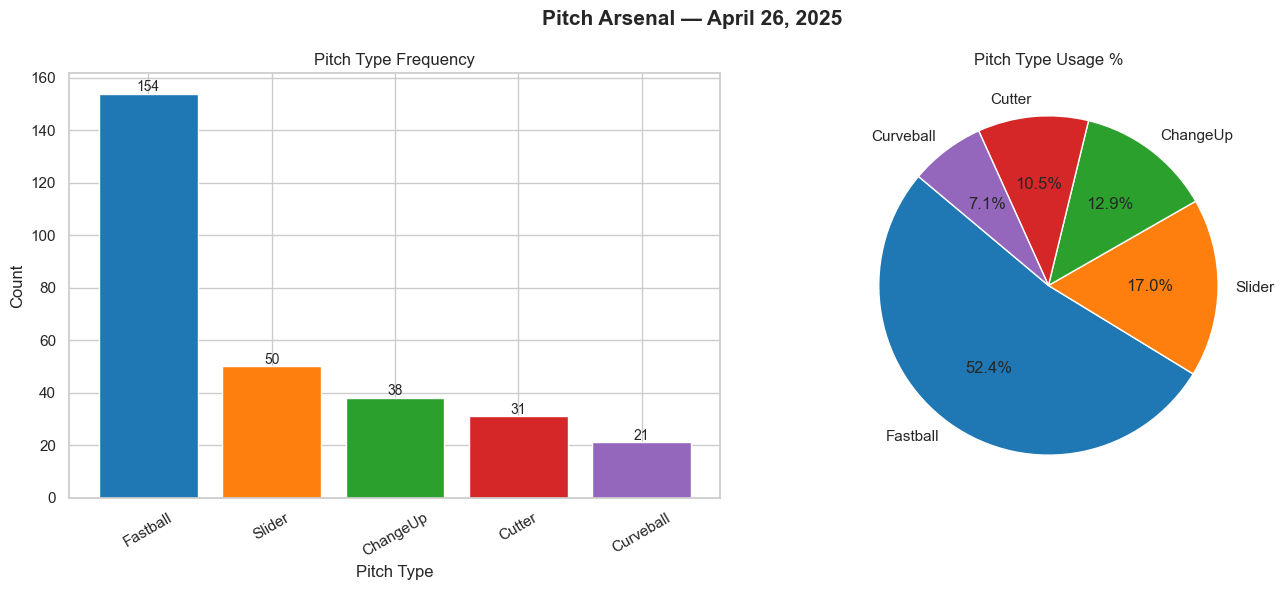


Summary:
           Count   Pct
PitchType             
Fastball     154  52.4
Slider        50  17.0
ChangeUp      38  12.9
Cutter        31  10.5
Curveball     21   7.1


In [4]:
pitch_counts = pitches['PitchType'].value_counts()
COLORS = sns.color_palette("tab10", len(pitch_counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(pitch_counts.index, pitch_counts.values, color=COLORS)
axes[0].set_title("Pitch Type Frequency")
axes[0].set_xlabel("Pitch Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(pitch_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=10)

# Pie chart
axes[1].pie(pitch_counts.values, labels=pitch_counts.index,
            autopct='%1.1f%%', colors=COLORS, startangle=140)
axes[1].set_title("Pitch Type Usage %")

plt.suptitle("Pitch Arsenal — April 26, 2025", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
print("\nSummary:")
print(pitch_counts.to_frame('Count').assign(Pct=lambda x: (x['Count']/x['Count'].sum()*100).round(1)))

## 5. Velocity Analysis by Pitch Type

Velocity Stats by Pitch Type (mph):
           Avg Velo  Max Velo  Min Velo  Std Dev
PitchType                                       
Fastball       87.5      94.6      76.9      3.7
Cutter         84.3      87.0      82.7      1.0
ChangeUp       81.0      84.8      75.9      2.7
Slider         78.3      85.1      69.3      3.6
Curveball      72.7      76.6      64.5      2.9


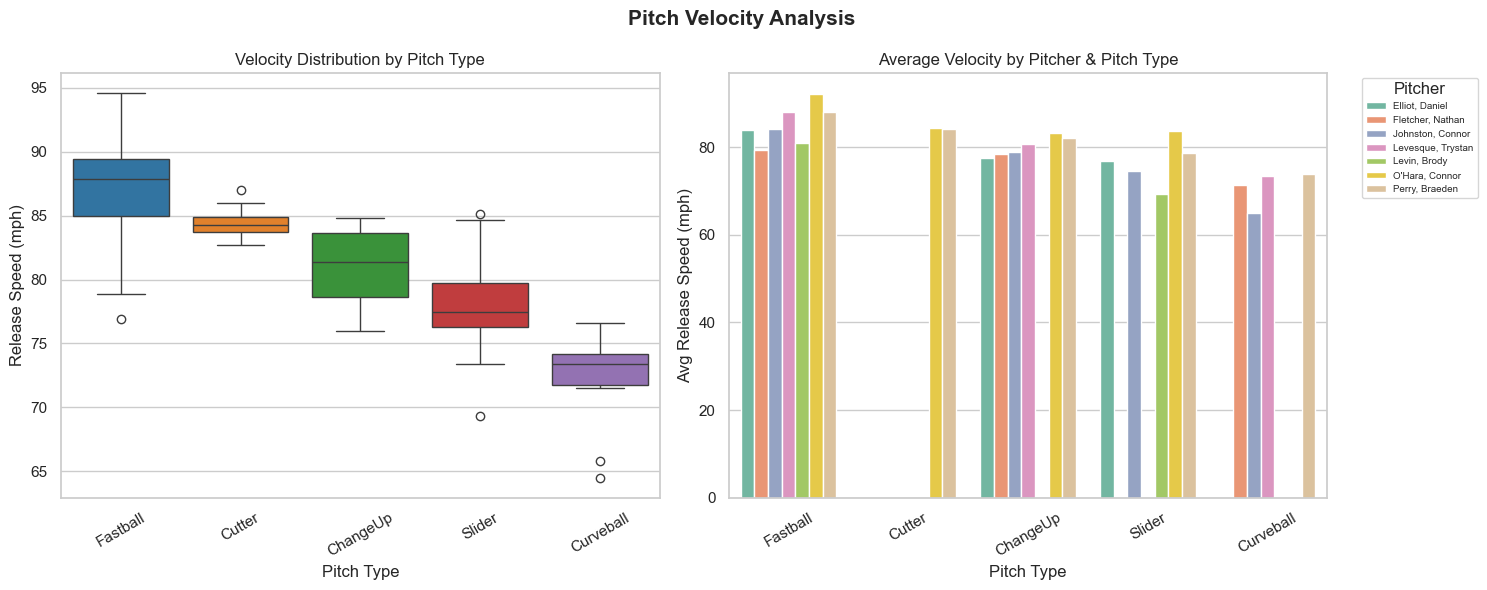

In [5]:
velo_stats = pitches.groupby('PitchType')['RelSpeed'].agg(['mean','max','min','std']).round(1)
velo_stats.columns = ['Avg Velo', 'Max Velo', 'Min Velo', 'Std Dev']
velo_stats = velo_stats.sort_values('Avg Velo', ascending=False)
print("Velocity Stats by Pitch Type (mph):")
print(velo_stats)

# Order pitch types by average velo for the plot
order = velo_stats.index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
sns.boxplot(data=pitches, x='PitchType', y='RelSpeed', order=order,
            palette='tab10', ax=axes[0])
axes[0].set_title("Velocity Distribution by Pitch Type")
axes[0].set_xlabel("Pitch Type")
axes[0].set_ylabel("Release Speed (mph)")
axes[0].tick_params(axis='x', rotation=30)

# Mean velo bar by pitcher + pitch type
pitcher_velo = pitches.groupby(['Pitcher', 'PitchType'])['RelSpeed'].mean().reset_index()
sns.barplot(data=pitcher_velo, x='PitchType', y='RelSpeed', hue='Pitcher',
            order=order, palette='Set2', ax=axes[1])
axes[1].set_title("Average Velocity by Pitcher & Pitch Type")
axes[1].set_xlabel("Pitch Type")
axes[1].set_ylabel("Avg Release Speed (mph)")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Pitcher', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)

plt.suptitle("Pitch Velocity Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Spin Rate Analysis

Spin Rate Stats by Pitch Type (RPM):
           Avg RPM  Max RPM  Min RPM  Std Dev
PitchType                                    
Slider      2256.0   2568.0   1974.0    158.0
Fastball    2145.0   2439.0   1738.0    162.0
Curveball   2036.0   2454.0   1698.0    185.0
Cutter      2029.0   2330.0   1870.0     87.0
ChangeUp    1796.0   2049.0   1281.0    189.0


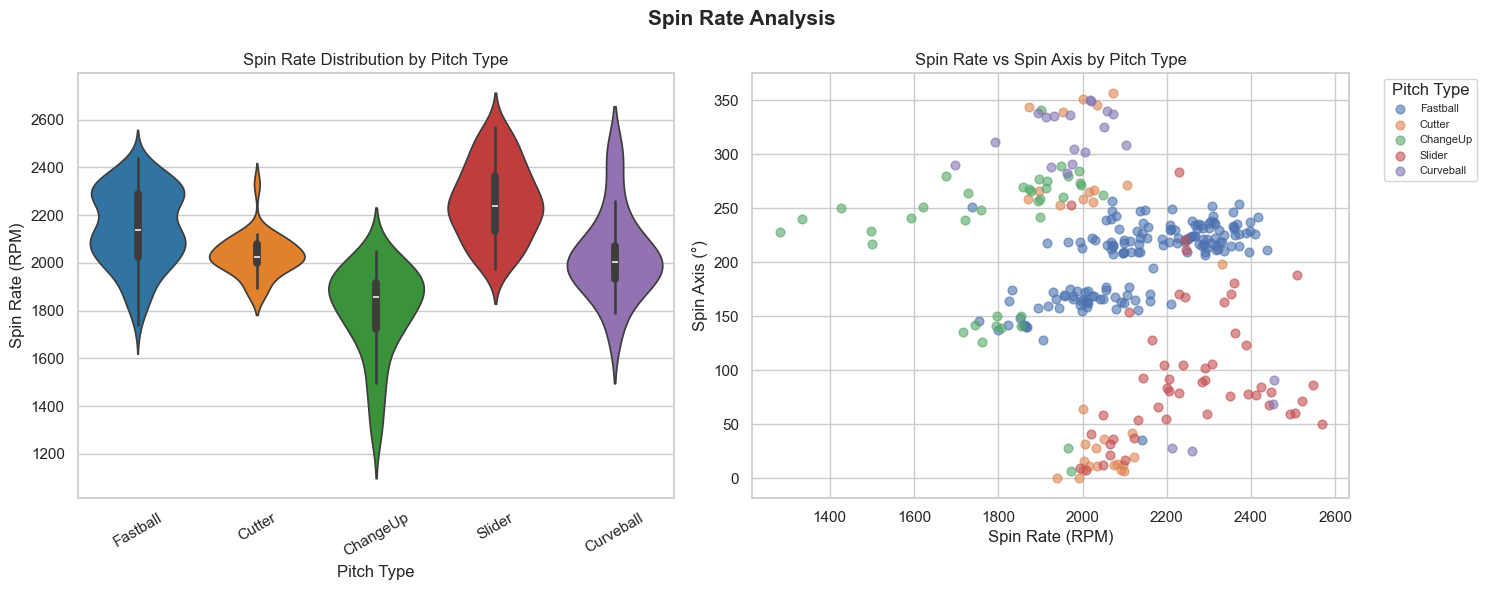

In [6]:
spin_stats = pitches.groupby('PitchType')['SpinRate'].agg(['mean','max','min','std']).round(0)
spin_stats.columns = ['Avg RPM', 'Max RPM', 'Min RPM', 'Std Dev']
print("Spin Rate Stats by Pitch Type (RPM):")
print(spin_stats.sort_values('Avg RPM', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Violin plot of spin rate
sns.violinplot(data=pitches, x='PitchType', y='SpinRate', order=order,
               palette='tab10', inner='box', ax=axes[0])
axes[0].set_title("Spin Rate Distribution by Pitch Type")
axes[0].set_xlabel("Pitch Type")
axes[0].set_ylabel("Spin Rate (RPM)")
axes[0].tick_params(axis='x', rotation=30)

# Spin axis scatter
spin_plot = pitches[pitches['SpinAxis'].notna()]
for pt in order:
    sub = spin_plot[spin_plot['PitchType'] == pt]
    axes[1].scatter(sub['SpinRate'], sub['SpinAxis'], label=pt, alpha=0.6, s=40)
axes[1].set_title("Spin Rate vs Spin Axis by Pitch Type")
axes[1].set_xlabel("Spin Rate (RPM)")
axes[1].set_ylabel("Spin Axis (°)")
axes[1].legend(title='Pitch Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.suptitle("Spin Rate Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Movement Profile (Horizontal vs Vertical Break)

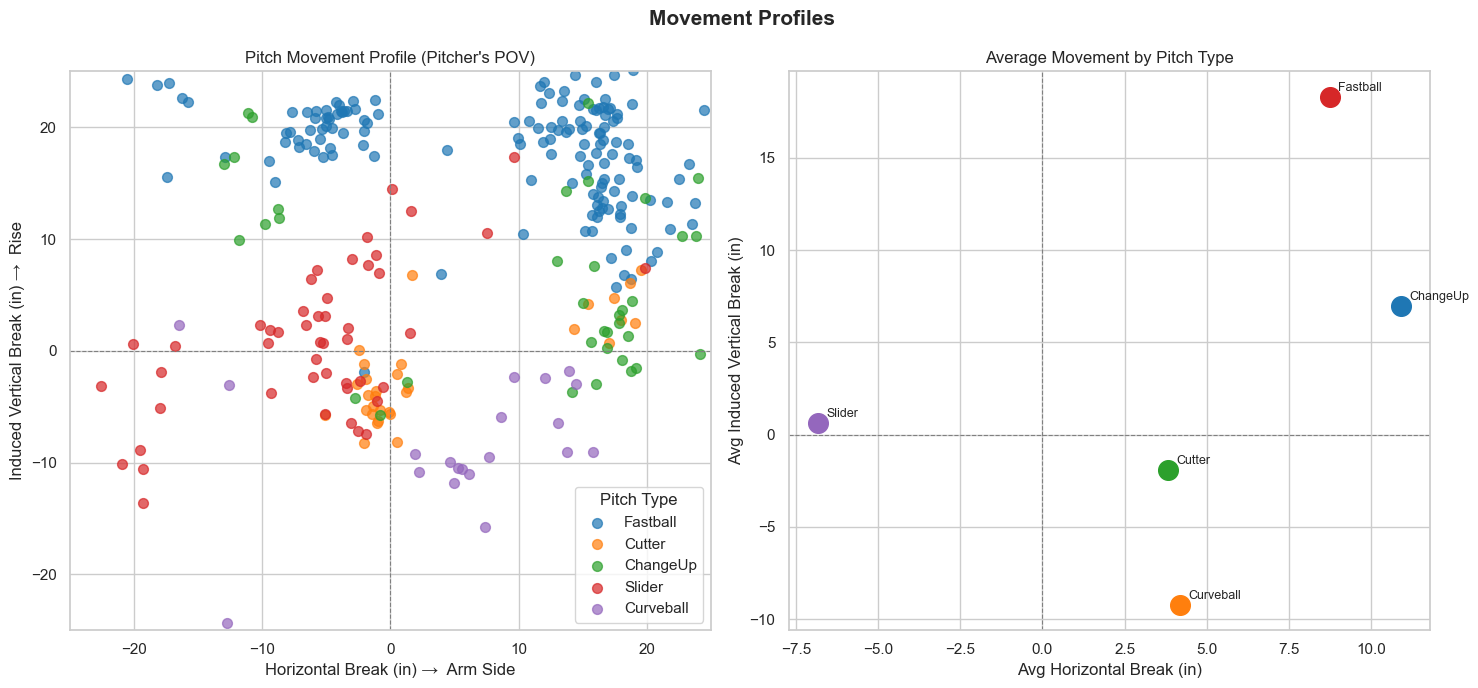


Average Movement (inches):
           HorzBreak  InducedVertBreak
PitchType                             
ChangeUp       10.89              6.99
Curveball       4.18             -9.22
Cutter          3.81             -1.89
Fastball        8.73             18.31
Slider         -6.84              0.65


In [7]:
move_data = pitches[pitches['HorzBreak'].notna() & pitches['InducedVertBreak'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Movement scatter — all pitches
for i, pt in enumerate(order):
    sub = move_data[move_data['PitchType'] == pt]
    axes[0].scatter(sub['HorzBreak'], sub['InducedVertBreak'],
                    label=pt, alpha=0.7, s=50, color=COLORS[i % len(COLORS)])

axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].axvline(0, color='gray', lw=0.8, ls='--')
axes[0].set_title("Pitch Movement Profile (Pitcher's POV)")
axes[0].set_xlabel("Horizontal Break (in) →  Arm Side")
axes[0].set_ylabel("Induced Vertical Break (in) →  Rise")
axes[0].legend(title='Pitch Type')
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)

# Average movement by pitch type
avg_movement = move_data.groupby('PitchType')[['HorzBreak','InducedVertBreak']].mean()
for i, (pt, row) in enumerate(avg_movement.iterrows()):
    axes[1].scatter(row['HorzBreak'], row['InducedVertBreak'],
                    s=200, color=COLORS[i % len(COLORS)], zorder=5)
    axes[1].annotate(pt, (row['HorzBreak'], row['InducedVertBreak']),
                     textcoords='offset points', xytext=(6, 4), fontsize=9)

axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].axvline(0, color='gray', lw=0.8, ls='--')
axes[1].set_title("Average Movement by Pitch Type")
axes[1].set_xlabel("Avg Horizontal Break (in)")
axes[1].set_ylabel("Avg Induced Vertical Break (in)")

plt.suptitle("Movement Profiles", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nAverage Movement (inches):")
print(avg_movement.round(2))

## 8. Release Point Analysis

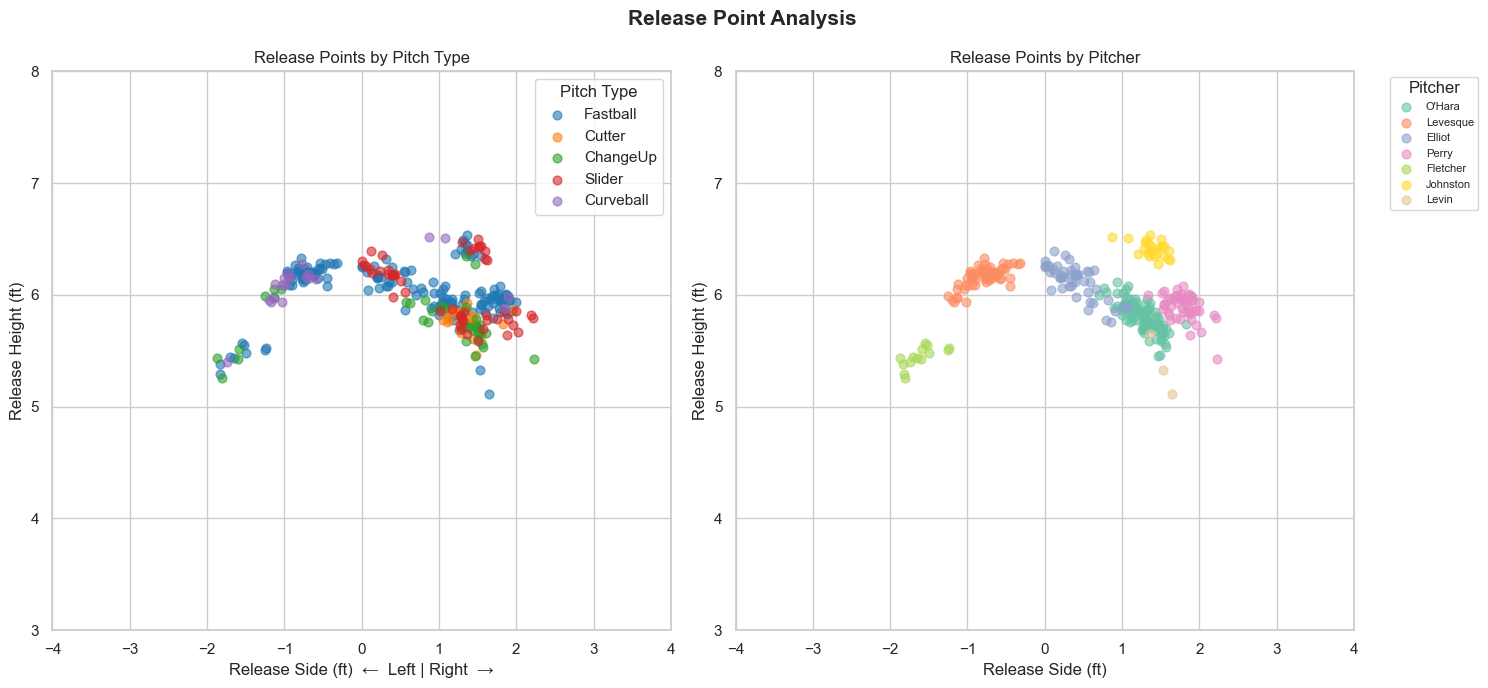


Average Extension by Pitcher (ft):
Pitcher
Perry, Braeden       6.06
Fletcher, Nathan     5.80
Johnston, Connor     5.41
Levesque, Trystan    5.34
O'Hara, Connor       5.28
Elliot, Daniel       4.74
Levin, Brody         4.68
Name: Extension, dtype: float64


In [8]:
rel_data = pitches[pitches['RelSide'].notna() & pitches['RelHeight'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# By pitch type
for i, pt in enumerate(order):
    sub = rel_data[rel_data['PitchType'] == pt]
    axes[0].scatter(sub['RelSide'], sub['RelHeight'],
                    label=pt, alpha=0.6, s=40, color=COLORS[i % len(COLORS)])
axes[0].set_title("Release Points by Pitch Type")
axes[0].set_xlabel("Release Side (ft)  ←  Left | Right  →")
axes[0].set_ylabel("Release Height (ft)")
axes[0].legend(title='Pitch Type')
axes[0].set_xlim(-4, 4)
axes[0].set_ylim(3, 8)

# By pitcher
pitchers = rel_data['Pitcher'].unique()
p_colors = sns.color_palette("Set2", len(pitchers))
for i, p in enumerate(pitchers):
    sub = rel_data[rel_data['Pitcher'] == p]
    axes[1].scatter(sub['RelSide'], sub['RelHeight'],
                    label=p.split(',')[0], alpha=0.6, s=40, color=p_colors[i])
axes[1].set_title("Release Points by Pitcher")
axes[1].set_xlabel("Release Side (ft)")
axes[1].set_ylabel("Release Height (ft)")
axes[1].legend(title='Pitcher', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(3, 8)

plt.suptitle("Release Point Analysis", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Extension
print("\nAverage Extension by Pitcher (ft):")
print(pitches.groupby('Pitcher')['Extension'].mean().round(2).sort_values(ascending=False))

## 9. Pitch Location and Strike Zone Visualization

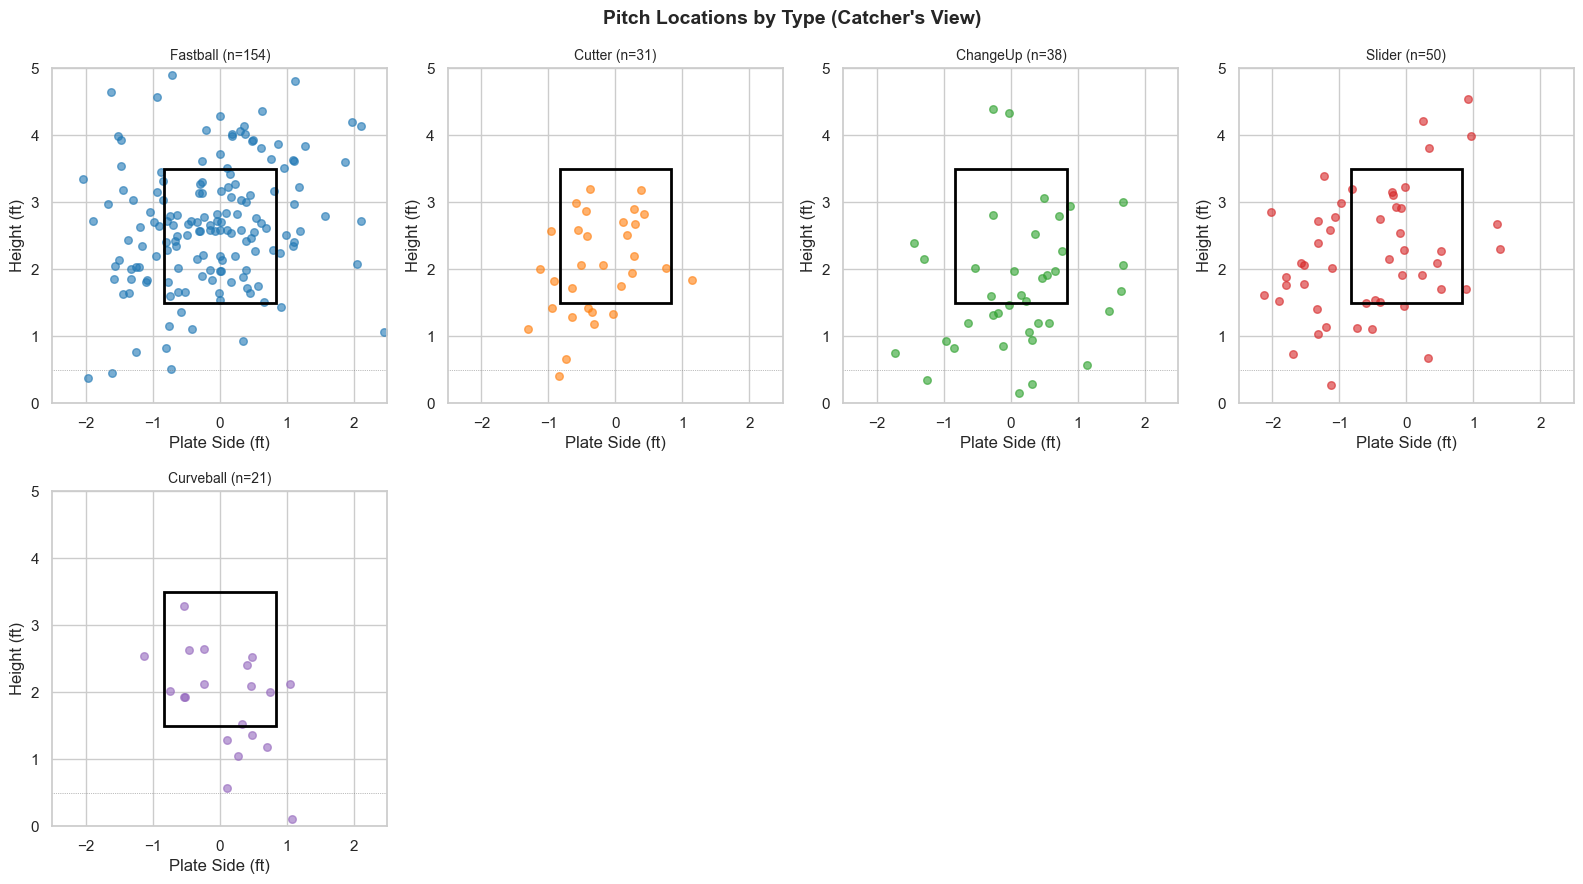

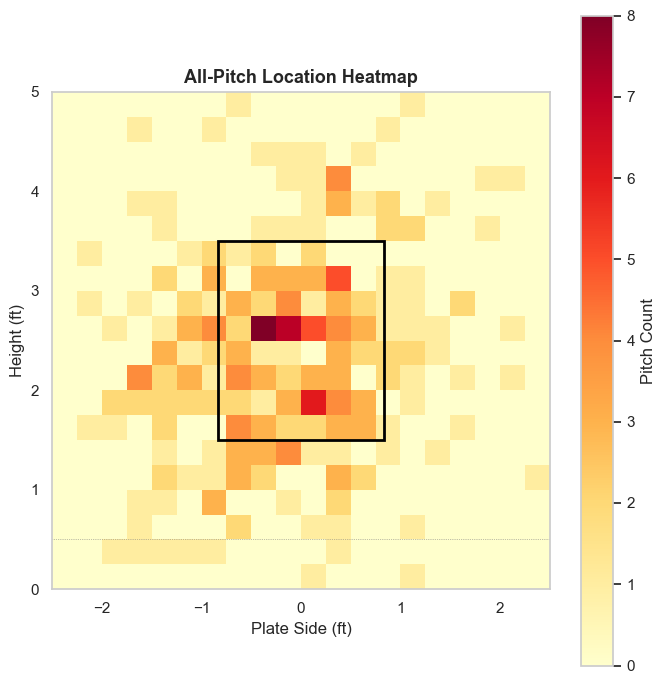

In [9]:
def draw_strike_zone(ax):
    """Draw the standard MLB strike zone rectangle on an axes."""
    zone = patches.Rectangle((-0.8333, 1.5), 1.6667, 2.0,
                              linewidth=2, edgecolor='black', facecolor='none')
    ax.add_patch(zone)
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(0, 5)
    ax.set_aspect('equal')
    ax.axhline(0.5, color='gray', lw=0.5, ls=':')  # ground
    ax.set_xlabel("Plate Side (ft)")
    ax.set_ylabel("Height (ft)")

loc_data = pitches[pitches['PlateLocSide'].notna() & pitches['PlateLocHeight'].notna()]

# --- Plot 1: All pitches by type ---
n_types = len(order)
n_cols = min(4, n_types)
n_rows = (n_types + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4.5 * n_rows))
axes_flat = np.array(axes).flatten()

for i, pt in enumerate(order):
    ax = axes_flat[i]
    sub = loc_data[loc_data['PitchType'] == pt]
    ax.scatter(sub['PlateLocSide'], sub['PlateLocHeight'],
               c=[COLORS[i % len(COLORS)]], alpha=0.6, s=30)
    draw_strike_zone(ax)
    ax.set_title(f"{pt} (n={len(sub)})", fontsize=10)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle("Pitch Locations by Type (Catcher's View)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Plot 2: Heatmap of all pitches ---
fig, ax = plt.subplots(figsize=(7, 7))
h = ax.hist2d(loc_data['PlateLocSide'], loc_data['PlateLocHeight'],
              bins=20, range=[[-2.5, 2.5], [0, 5]], cmap='YlOrRd')
fig.colorbar(h[3], ax=ax, label='Pitch Count')
draw_strike_zone(ax)
ax.set_title("All-Pitch Location Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Pitcher Performance Metrics

Performance Metrics by Pitch Type:
           Pitches  Strike%  Whiff%  Swing%  InPlay%  Avg Velo  Avg Spin  Avg IVB  Avg HB
PitchType                                                                                
Fastball     154.0     45.5    17.3    48.7     18.2      87.5    2145.0     18.3     8.7
Slider        50.0     34.0    14.3    28.0     18.0      78.3    2256.0      0.7    -6.8
ChangeUp      38.0     39.5    50.0    36.8     13.2      81.0    1796.0      7.0    10.9
Cutter        31.0     71.0    26.1    74.2     19.4      84.3    2029.0     -1.9     3.8
Curveball     21.0     42.9    12.5    38.1     23.8      72.7    2036.0     -9.2     4.2

Performance Metrics by Pitcher:
                   Pitches  Strike%  Whiff%  Swing%  InPlay%  Avg Velo  Avg Spin  Avg IVB  Avg HB
Pitcher                                                                                          
O'Hara, Connor        93.0     59.1    26.5    52.7     14.0      86.9    2094.0      3.4     9.9
Levesque

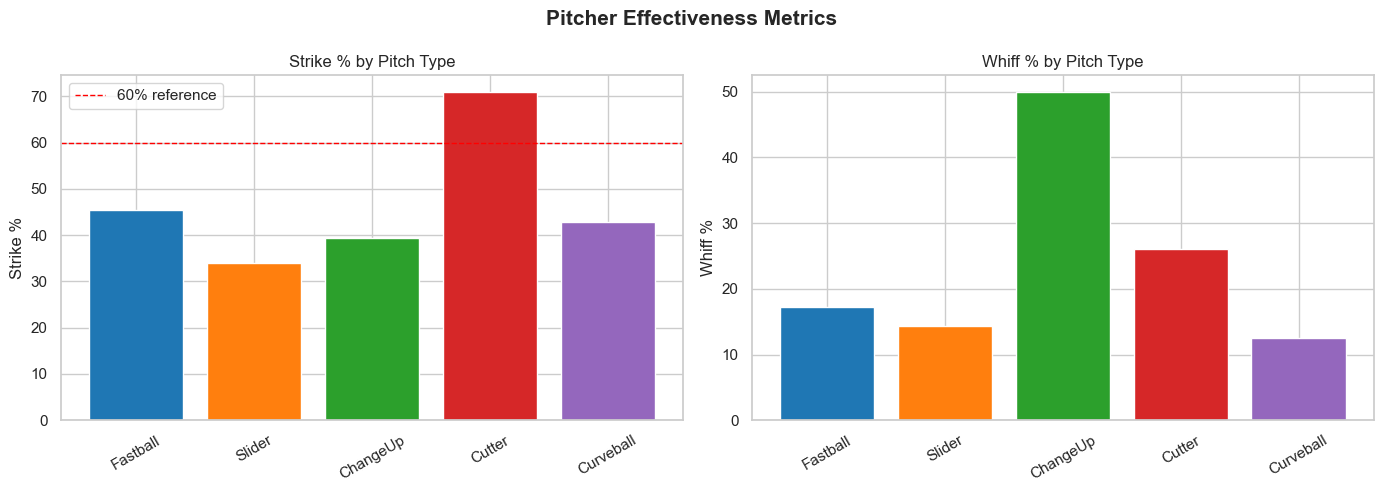

In [10]:
def perf_metrics(grp):
    total = len(grp)
    strikes = grp['IsStrike'].sum()
    whiffs  = grp['IsWhiff'].sum()
    swings  = grp['IsSwing'].sum()
    in_play = grp['PitchCall'].str.contains('InPlay', case=False, na=False).sum()
    return pd.Series({
        'Pitches':      total,
        'Strike%':      round(strikes / total * 100, 1) if total else 0,
        'Whiff%':       round(whiffs  / swings * 100, 1) if swings else 0,
        'Swing%':       round(swings  / total * 100, 1) if total else 0,
        'InPlay%':      round(in_play / total * 100, 1) if total else 0,
        'Avg Velo':     round(grp['RelSpeed'].mean(), 1),
        'Avg Spin':     round(grp['SpinRate'].mean(), 0),
        'Avg IVB':      round(grp['InducedVertBreak'].mean(), 1),
        'Avg HB':       round(grp['HorzBreak'].mean(), 1),
    })

# ── Per pitch-type ──────────────────────────────────────────────────────────
pitch_metrics = pitches.groupby('PitchType').apply(perf_metrics).sort_values('Pitches', ascending=False)
print("Performance Metrics by Pitch Type:")
print(pitch_metrics.to_string())

# ── Per pitcher ──────────────────────────────────────────────────────────────
print("\nPerformance Metrics by Pitcher:")
pitcher_metrics = pitches.groupby('Pitcher').apply(perf_metrics).sort_values('Pitches', ascending=False)
print(pitcher_metrics.to_string())

# ── Visualise Strike% & Whiff% ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pm = pitch_metrics.reset_index()
axes[0].bar(pm['PitchType'], pm['Strike%'], color=COLORS[:len(pm)])
axes[0].axhline(60, color='red', ls='--', lw=1, label='60% reference')
axes[0].set_title("Strike % by Pitch Type")
axes[0].set_ylabel("Strike %")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

axes[1].bar(pm['PitchType'], pm['Whiff%'], color=COLORS[:len(pm)])
axes[1].set_title("Whiff % by Pitch Type")
axes[1].set_ylabel("Whiff %")
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle("Pitcher Effectiveness Metrics", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
         swing decisions     
national avergage     

pitching velocity vs exit velocity (batting)